# Setup

## Packages

In [125]:
from preamble import *
from natural_units_GeV import *

from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point


## Parameters

In [126]:
# B1422+231 parameters from Cosmograil 2012

# distances
z_lens = 0.34
z_source = 3.62

# coordinates of images and galaxy/group
coord_ref = SkyCoord('14h24m38.09s', '+22d56m00.60s', frame='icrs') # reference coordinate
coord_ref = np.asarray([coord_ref.ra.degree, coord_ref.dec.degree]) * degree # in rad
cos_dec = np.cos(coord_ref[1]) # cosine of the declination
theta = np.asarray([[0.3860,0.3169],[0.,0.],[-0.3360,-0.7516],[0.9470,-0.8012]]) # lens image locations in ra, dec (in arcsec)
print('theta: \n',theta)
theta_lens = np.asarray([0.7321,-0.6390]) # lens galaxy location in ra, dec (in arcsec)
labels = ['A','B','C','D']

# flux
flux_ratios = np.array([1, 1.116, 0.59, 0.032]) # flux ratios between the images (relative to A)

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]


# Macro lens model (1 lens + shear)

## Fiducial

In [127]:
# lens parameters from Cosmograil 2012
theta_E = 0.771 # Einstein radius in arcsec
ell = 0.28 # ellipticity
theta_e = -56.96 * degree # position angle of the ellipticity
e1 = ell * np.cos(2*theta_e) # ellipticity component 1
e2 = ell * np.sin(2*theta_e) # ellipticity component 2
gamma_ext = 0.174 # external shear
theta_gamma_ext = 52.45 * degree # position angle of the external shear (opposite sign in Cosmograil but this gives much better results)
gamma1 = gamma_ext * np.cos(2*theta_gamma_ext) # shear component 1
gamma2 = gamma_ext * np.sin(2*theta_gamma_ext) # shear component 2

In [128]:
lens_model_list = ['SIE', 'SHEAR'] # lens model includes singular isothermal ellipsoid and external shear
lens_model = LensModel(lens_model_list=lens_model_list, z_lens=z_lens, z_source=z_source, cosmo=cosmo) # initialize lens model
kwargs_sie = {'theta_E': theta_E, 'e1': e1, 'e2': e2, 'center_x': theta_lens[0], 'center_y': theta_lens[1]} # SIE parameters
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}  # shear parameters
kwargs_lens = [kwargs_sie, kwargs_shear] # list of lens model kwargs

In [129]:
# calculate source plane coordinate 
beta = np.transpose(lens_model.ray_shooting(theta[:,0], theta[:,1], kwargs_lens))
print('beta: \n', beta)

beta: 
 [[ 0.51450018 -0.43604382]
 [ 0.580067   -0.38998055]
 [ 0.55782628 -0.47382993]
 [ 0.5020563  -0.58626552]]


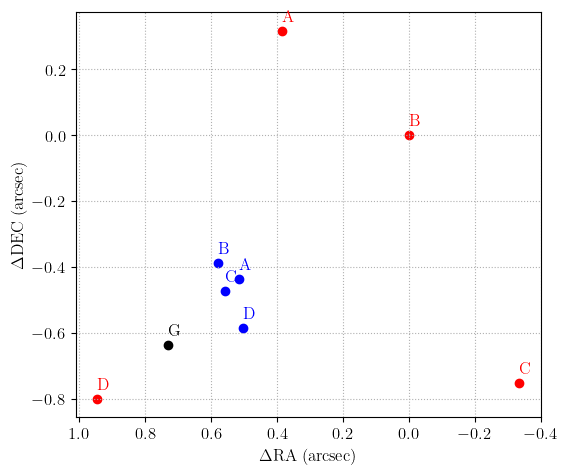

In [130]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');


## Fit with floating lens parameters, fixed shear

5 free parameters: theta_E, e1, e2, theta_lens (2)

In [131]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens) # take as initial guess the Cosmograil solution
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': 0.771, 'e1': -0.11352899513903059, 'e2': -0.2559514939646221, 'center_x': 0.7321, 'center_y': -0.639}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


In [132]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-12)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': 0.776260755455916, 'e1': 0.06509412017886437, 'e2': -0.14697342120583357, 'center_x': 0.7281005110145559, 'center_y': -0.6503824875321547}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


/Users/kvantilburg/anaconda3/envs/quasar-lens/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [133]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72810051 -0.65038249]
beta_new: 
 [[ 0.52671285 -0.50720816]
 [ 0.52672567 -0.5072982 ]
 [ 0.52691308 -0.50736986]
 [ 0.52675307 -0.50714268]]
beta_fit: 
 [ 0.52677617 -0.50725473]


In [134]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
theta_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_fit),len(theta)))
for i, point_fit in enumerate(theta_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_fit = theta_fit[np.argsort(closest_indices)] # Sort theta_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_fit: \n', theta_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_fit: 
 [[ 3.86246611e-01  3.16962678e-01]
 [-4.30402489e-04 -5.15211414e-04]
 [-3.36087228e-01 -7.51132287e-01]
 [ 9.47075309e-01 -8.01215585e-01]]


In [135]:
mag = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit = lens_model.magnification(theta_fit[:,0], theta_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
print('mag: \n', mag) 
print('mag_fit: \n', mag_fit) 

mag: 
 [ 6.85514628 -8.69624752  4.41193765 -0.32705635]
mag_fit: 
 [ 6.84992009 -8.68443701  4.41569408 -0.32717149]


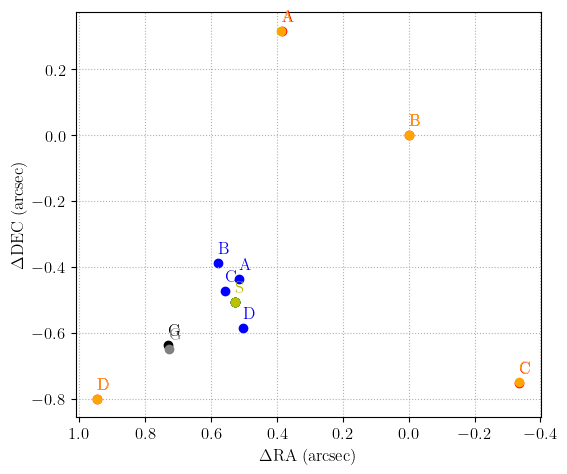

In [136]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_fit)):
    ax.scatter(theta_fit[i,0],theta_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_fit[i,0],theta_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');

# Fit with floating lens parameters and shear

7 free parameters: theta_E, e1, e2, theta_lens (2), gamma1, gamma2

In [137]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE_SHEAR') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens_fit) # take as initial guess the previous fit
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': 0.776260755455916, 'e1': 0.06509412017886437, 'e2': -0.14697342120583357, 'center_x': 0.7281005110145559, 'center_y': -0.6503824875321547}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


In [138]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-14)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': 0.7761938936468246, 'e1': 0.06470746299724082, 'e2': -0.14701338954709725, 'center_x': 0.7279119221696818, 'center_y': -0.6503046841699268}, {'gamma1': -0.0450419445133418, 'gamma2': 0.16806910255742138}]


/Users/kvantilburg/anaconda3/envs/quasar-lens/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)


In [139]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72791192 -0.65030468]
beta_new: 
 [[ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]]
beta_fit: 
 [ 0.52679096 -0.50714071]


In [140]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
theta_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_fit),len(theta)))
for i, point_fit in enumerate(theta_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_fit = theta_fit[np.argsort(closest_indices)] # Sort theta_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_fit: \n', theta_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_fit: 
 [[ 3.86000000e-01  3.16900000e-01]
 [-1.95484782e-12 -2.79422925e-12]
 [-3.36000000e-01 -7.51600000e-01]
 [ 9.47000000e-01 -8.01200000e-01]]


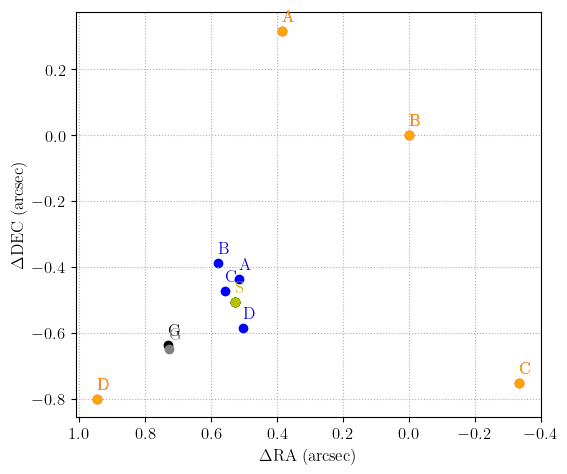

In [142]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_fit)):
    ax.scatter(theta_fit[i,0],theta_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_fit[i,0],theta_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');

In [143]:
psi_fit = lens_model.potential(theta[:,0], theta[:,1], kwargs_lens_fit)  # lensing potential at image positions (in arcsec^2)
alpha_fit = np.transpose(lens_model.alpha(theta[:,0], theta[:,1], kwargs_lens_fit)) # deflection angles at image positions (in arcsec)
npt.assert_almost_equal(theta_fit - alpha_fit, beta_new, decimal=10) # check that the lens equation is satisfied at the best-fit image positions
print('psi_fit: \n', psi_fit)
print('alpha_fit: \n', alpha_fit)

psi_fit: 
 [0.80033236 0.7132534  0.8678773  0.06059264]
alpha_fit: 
 [[-0.14079096  0.82404071]
 [-0.52679096  0.50714071]
 [-0.86279096 -0.24445929]
 [ 0.42020904 -0.29405929]]


### Distortions and magnification

The change in the deflection field results in distortions in extended images and magnification effects in unresolved small sources.

We can define the lensing Jacobian $\mathbf{A}$ as the differential of the lens equation

$$ A_{ij} \equiv {\frac {\partial \beta _{i}}{\partial \theta _{j}}}=\delta _{ij}-{\frac {\partial \alpha _{i}}{\partial \theta _{j}}}=\delta _{ij}-{\frac {\partial ^{2}\psi }{\partial \theta _{i}\partial \theta _{j}}}
=\left[{\begin{array}{c c }1-\kappa -\gamma _{1}&\gamma _{2}\\\gamma _{2}&1-\kappa +\gamma _{1}\end{array}}\right]
$$

where $\delta_{ij}$ is the Kronecker delta and we have define the derivatives
$$
\kappa \equiv{\partial \psi  \over 2\partial \theta _{1}\partial \theta _{1}}+{\partial \psi  \over 2\partial \theta _{2}\partial \theta _{2}},~\gamma _{1}\equiv {\partial \psi  \over 2\partial \theta _{1}\partial \theta _{1}}-{\partial \psi  \over 2\partial \theta _{2}\partial \theta _{2}},~\gamma _{2}\equiv {\partial \psi  \over \partial \theta _{1}\partial \theta _{2}}.
$$

We see that in this way, convergence is a property of a vector field rather a physical quantity. It happens that this vector field quantity corresponds to scales surface mass density (for a single plane deflector).

The determinant of the Jacobian $\mathbf{A}$ defines the mapping of an infinitesimal area element from the  image plane to the source plane. Lensing perserves surface brightness. It is the differential change in area that causes different amplifications due to lensing (i.e. the surface brightness of a star has always the same brightness and temperature, but the observed angular size of the star can change by lensing).

The lensing amplification (or magnification) $\mu$, the ratio of lensed observed flux divided by the intrinsic unlensed flux is given by the inverse determinant of the Jacobian

$$ \mu \equiv \frac{F_{\rm lensed}}{F_{\rm unlensed}} = 1/\det(A_{ij})={1 \over (1-\kappa )^{2}-\gamma _{1}^{2}-\gamma _{2}^{2}}.
$$

The determinant has a sign (can be positive or negative). A negative sign means that the infinitesimal image is mirrored (changed parity) in respect to the unlensed source.

In [159]:
mag_fit = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit_2 = lens_model.magnification(theta_fit[:,0], theta_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
flux_ratios_fit = np.abs(mag_fit[:]/mag_fit[0]) # flux ratios of best-fit image positions (relative to image A)
print('mag_fit: \n', mag_fit) 
print('mag_fit_2: \n', mag_fit_2) 
print('flux_ratios: \n', flux_ratios)
print('flux_ratios_fit: \n', flux_ratios_fit)

mag_fit: 
 [ 6.85806851 -8.6880414   4.41141542 -0.32744648]
mag_fit_2: 
 [ 6.85805545 -8.68799619  4.4114407  -0.32744648]
flux_ratios: 
 [1.    1.116 0.59  0.032]
flux_ratios_fit: 
 [1.         1.26683503 0.64324458 0.04774617]


In [177]:
hessian_fit = np.reshape(np.transpose(lens_model.hessian(theta[:,0], theta[:,1], kwargs_lens_fit)), # Hessian; second derivative of the potential
                         (len(theta),2,2))  # reshape to (n_points,2,2)
kappa_fit = lens_model.kappa(theta[:,0], theta[:,1], kwargs_lens_fit)  # convergence
gamma1_fit, gamma2_fit = lens_model.gamma(theta[:,0], theta[:,1], kwargs_lens_fit) # shear components
jacobian_fit = np.asarray(len(theta) * [[[1,0],[0,1]]]) - hessian_fit # Jacobian of the lens mapping
inv_jacobian_fit = np.linalg.inv(jacobian_fit) # inverse of the Jacobian


# check whether the definitions are correct
npt.assert_almost_equal(kappa_fit, 1/2. * (hessian_fit[:,0,0] + hessian_fit[:,1,1]), decimal=10) # check that the convergence is the trace of the Hessian
npt.assert_almost_equal(gamma1_fit, 1/2. * (hessian_fit[:,0,0] - hessian_fit[:,1,1]), decimal=10) # check that the first shear component is the difference of the diagonal elements of the Hessian
npt.assert_almost_equal(gamma2_fit, hessian_fit[:,0,1], decimal=10) # check that the second shear component is the off-diagonal element of the Hessian
npt.assert_almost_equal(mag, 1/((1-kappa_fit)**2 - gamma1_fit**2 - gamma2_fit**2), decimal=10) # check that the magnification is the inverse of the determinant of the Jacobian
npt.assert_almost_equal(mag, np.linalg.det(inv_jacobian_fit), decimal=10) # check that the magnification is the inverse of the determinant of the Jacobian

#print('hessian_fit: \n', hessian_fit)
print('jacobian_fit: \n', jacobian_fit)
#print('inv_jacobian_fit: \n', inv_jacobian_fit)
print('kappa_fit: \n', kappa_fit)
# print('gamma1_fit: \n', gamma1_fit)
# print('gamma2_fit: \n', gamma2_fit)

jacobian_fit: 
 [[[ 0.36094563 -0.40990015]
  [-0.40990015  0.86947109]]

 [[ 0.63421289 -0.62792786]
  [-0.62792786  0.44021916]]

 [[ 1.03844826 -0.09882543]
  [-0.09882543  0.22769654]]

 [[-0.05852845 -1.7703681 ]
  [-1.7703681  -1.37145358]]]
kappa_fit: 
 [0.38479164 0.46278398 0.3669276  1.71499101]


### Plot

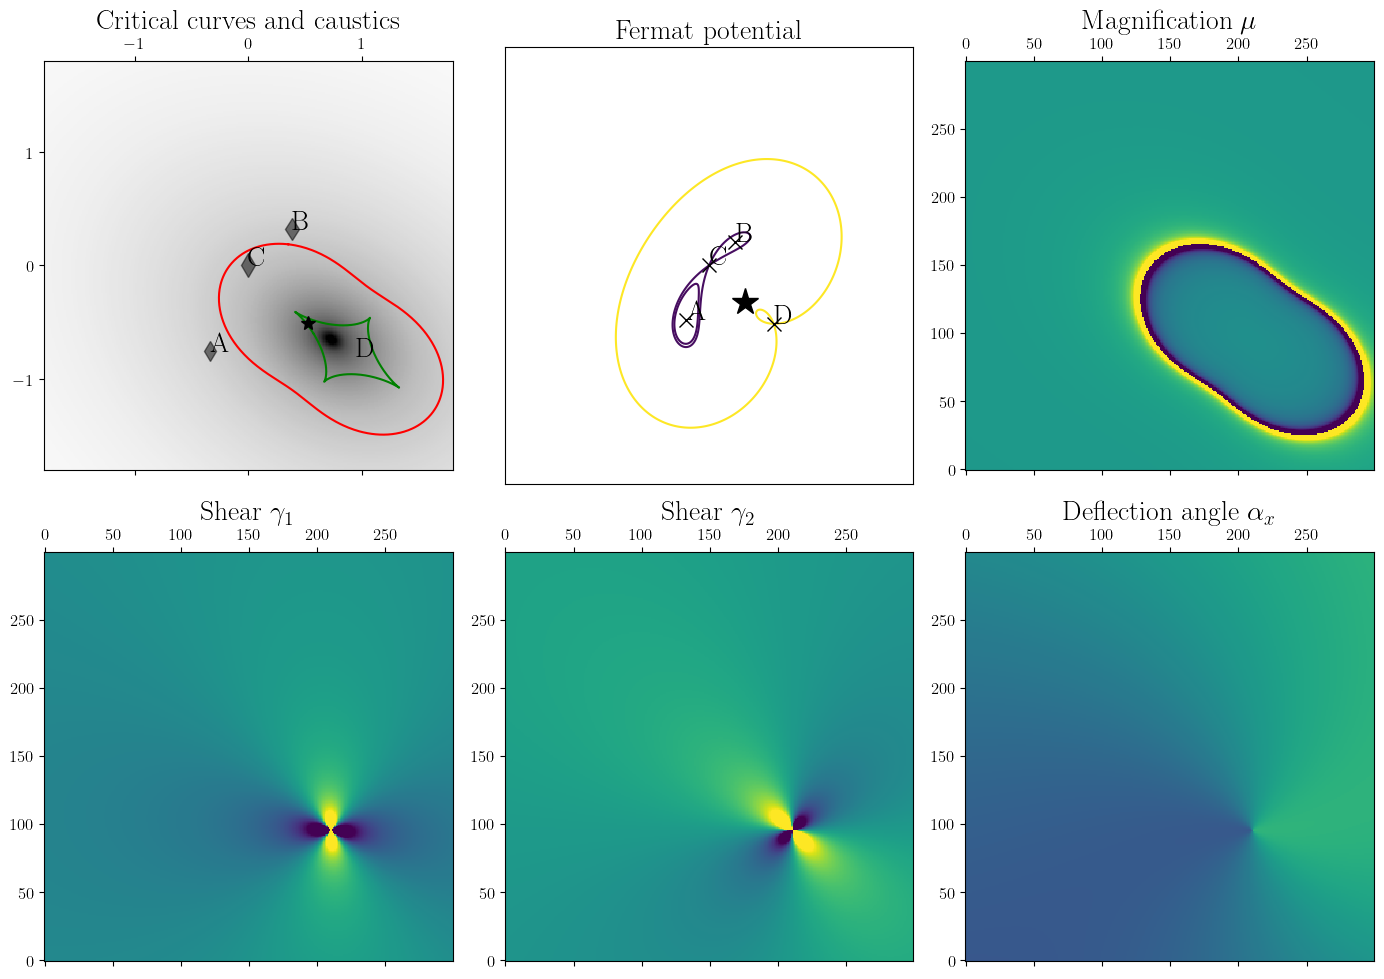

In [189]:
from lenstronomy.Plots.lens_plot import lens_model_plot, arrival_time_surface
from lenstronomy.Util import util

# coordinate grid for plotting
num_pix = 300
delta_pix = 0.012

x_grid, y_grid = util.make_grid(numPix=num_pix, deltapix=delta_pix)

kwargs_lens_plot = {'with_caustics': True, 'fast_caustic': True, 'point_source': True,
                   'with_convergence': True, 'numPix': num_pix, 'deltaPix': delta_pix}

f, axex = plt.subplots(2, 3, figsize=(14, 10))

# image positions, critical curves and caustics
lens_model_plot(axex[0, 0], lens_model, kwargs_lens_fit, sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], **kwargs_lens_plot)
axex[0, 0].set_title('Critical curves and caustics', fontsize=20)

arrival_time_surface(axex[0, 1], lens_model, kwargs_lens_fit, sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1],
                     deltaPix=delta_pix, point_source=True)
axex[0, 1].set_title('Fermat potential', fontsize=20)

mu = lens_model.magnification(x_grid, y_grid, kwargs_lens_fit)
mu = util.array2image(mu)
axex[0, 2].matshow(mu, origin='lower', vmin=-20, vmax=20)
axex[0, 2].set_title(r'Magnification $\mu$', fontsize=20)

gamma1_plot, gamma2_plot = lens_model.gamma(x_grid, y_grid, kwargs_lens_fit)
axex[1, 0].matshow(util.array2image(gamma1_plot), origin='lower', vmin=-2, vmax=2)
axex[1, 0].set_title(r'Shear $\gamma_1$', fontsize=20)

axex[1, 1].matshow(util.array2image(gamma2_plot), origin='lower', vmin=-2, vmax=2)
axex[1, 1].set_title(r'Shear $\gamma_2$', fontsize=20)


alpha_x, alpha_y = lens_model.alpha(x_grid, y_grid, kwargs_lens_fit)
axex[1, 2].matshow(util.array2image(alpha_x), origin='lower', vmin=-2, vmax=2)
axex[1, 2].set_title(r'Deflection angle $\alpha_x$', fontsize=20)

plt.tight_layout()
plt.show()

In [ ]:


gamma1, gamma2 = lens_model_sie_shear.gamma(x_grid, y_grid, kwargs_lens_sie_shear)

axex[1, 0].matshow(util.array2image(gamma1), origin='lower', vmin=-2, vmax=2)
axex[1, 0].set_title(r'Shear $\gamma_1$', fontsize=20)

axex[1, 1].matshow(util.array2image(gamma2), origin='lower', vmin=-2, vmax=2)
axex[1, 1].set_title(r'Shear $\gamma_2$', fontsize=20)


alpha_x, alpha_y = lens_model_sie_shear.alpha(x_grid, y_grid, kwargs_lens_sie_shear)
axex[1, 2].matshow(util.array2image(alpha_x), origin='lower', vmin=-2, vmax=2)
axex[1, 2].set_title(r'Deflection angle $\alpha_x$', fontsize=20)

plt.tight_layout()
plt.show()